# 8.3.1 岭回归与参数收缩

## 学习目标与先修知识

推导二范数（norm）惩罚解，解释共线性、正则强度与不唯一。

先修：6.4最小二乘、8.1二次曲率与8.2条件数（condition number）。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

两个候选清除机制随浓度（concentration）近乎同步变化。很小的测量扰动就会令两系数大幅抵消；能否以一些拟合偏差换取更稳定的系数？

In [1]:
import math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]
BLUE, PINK, GREEN, GRAY = "#327cac", "#c35178", "#338b7c", "#68768a"

## 初步实验

In [2]:
u=np.linspace(.2,2,24);v=u+.015*np.cos(np.arange(24));X=np.column_stack([u,v]);y=1.5*u+.02*np.sin(np.arange(24))
for data in [y,y+.01*np.cos(np.arange(24))]:
    print('无惩罚最小二乘',np.linalg.lstsq(X,data,rcond=None)[0])

无惩罚最小二乘 [1.44872166 0.05145662]
无惩罚最小二乘 [0.782055   0.71812329]


## 模型假设

候选设计矩阵（design matrix）和观测（observation）已无量纲（dimensionless）化；目标使用平均平方损失。截距固定为零。惩罚施加在指定坐标系的全部系数上，λ≥0；改变尺度会改变惩罚的实际含义。稳定化不补充原本没有的机制信息。

## 数学解释与推导


岭回归（ridge regression）在平均损失上加入二范数平方惩罚：
$$J_\lambda(\beta)=\frac{1}{2n}\|X\beta-y\|^2+\frac\lambda2\|\beta\|^2.$$
逐项求导得到 $(X^TX/n+\lambda I)\beta=X^Ty/n$。$X^TX/n$ 半正定（positive semidefinite），故
$\lambda>0$ 时所有特征值（eigenvalue）都加 $\lambda$，目标严格凸且有唯一解。
$\lambda=0$ 时须检查列满秩（rank）；列不满秩的最小二乘最小值仍可达到，但系数不唯一。

令 $X^TX/n=V\operatorname{diag}(d_j)V^T$，$b=X^Ty/n$。
在每个特征方向，$v_j^T\hat\beta_\lambda=(v_j^Tb)/(d_j+\lambda)$。
若 $d_j>0$，相对无惩罚系数缩小 $d_j/(d_j+\lambda)$；小曲率方向收缩更多。
$d_j=0$ 时 $v_j^Tb=0$，正惩罚取该方向为零。
“收缩”指这个特征坐标；一般不能要求原坐标每个系数绝对值都单调减小。

偏差与稳定性的折中由数据、尺度和任务决定，不能仅按训练误差选λ。
正惩罚使代数解唯一，不等于两个共线机制已能被数据区分。
截距通常另行处理而不惩罚：8.3.3通过只在训练集（training set）上中心化来实现。

若另加概率（probability）假设：独立误差为已知方差（variance） $\sigma^2$ 的高斯分布（Gaussian distribution），系数先验（prior）为 $N(0,\tau^2I)$，则负对数后验（posterior）除去常数为
$\|X\beta-y\|^2/(2\sigma^2)+\|\beta\|^2/(2\tau^2)$。
乘以 $\sigma^2/n$ 即得到本节目标，且 $\lambda=\sigma^2/(n\tau^2)$。
在这个似然（likelihood）与先验的组合下，岭解就是最大后验点；后验的分布（distribution）形状还需另行计算。


## 核心实现

按上述推导逐步计算；保留明确的更新预算与返回标签。

In [3]:
def solve_linear(matrix, right):
    """Partial-pivot elimination for the tiny classroom systems."""
    rows = [list(map(float, row))+[float(value)] for row, value in zip(matrix, right)]
    size = len(rows)
    for column in range(size):
        pivot = max(range(column, size), key=lambda i: abs(rows[i][column]))
        if abs(rows[pivot][column]) < 1e-12:
            return None
        rows[column], rows[pivot] = rows[pivot], rows[column]
        scale = rows[column][column]
        rows[column] = [value/scale for value in rows[column]]
        for i in range(size):
            if i != column:
                factor = rows[i][column]
                rows[i] = [a-factor*b for a, b in zip(rows[i], rows[column])]
    return [row[-1] for row in rows]


def ridge_fit(design, observed, penalty):
    count, width = len(design), len(design[0])
    matrix = [[sum(row[i]*row[j] for row in design)/count+(penalty if i==j else 0)
               for j in range(width)] for i in range(width)]
    right = [sum(row[i]*y for row, y in zip(design, observed))/count for i in range(width)]
    coefficients = solve_linear(matrix, right)
    return coefficients, 'unique' if coefficients is not None else 'nonunique'

## 对照实验

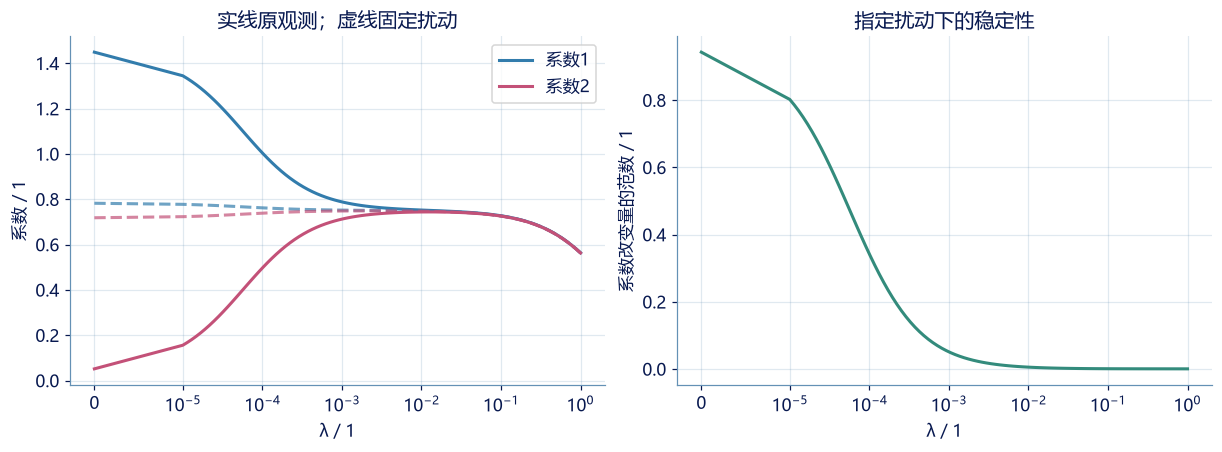

In [4]:
lambdas=np.r_[0.,np.logspace(-5,0,90)];paths=[];perturbed=[]
for lam in lambdas:
    paths.append(ridge_fit(X.tolist(),y.tolist(),float(lam))[0])
    perturbed.append(ridge_fit(X.tolist(),(y+.01*np.cos(np.arange(24))).tolist(),float(lam))[0])
paths=np.array(paths);perturbed=np.array(perturbed)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for j,color in enumerate([BLUE,PINK]):
    axes[0].plot(lambdas,paths[:,j],color=color,label=f'系数{j+1}')
    axes[0].plot(lambdas,perturbed[:,j],color=color,ls='--',alpha=.7)
axes[0].set_xscale('symlog',linthresh=1e-5)
axes[0].set(xlabel='λ / 1',ylabel='系数 / 1',title='实线原观测；虚线固定扰动');axes[0].legend()
axes[1].plot(lambdas,np.linalg.norm(paths-perturbed,axis=1),color=GREEN)
axes[1].set_xscale('symlog',linthresh=1e-5)
axes[1].set(xlabel='λ / 1',ylabel='系数改变量的范数 / 1',title='指定扰动下的稳定性');plt.show()

### 独立核验与边界

In [5]:
for lam in [0.,.01,1.]:
    got,status=ridge_fit(X.tolist(),y.tolist(),lam)
    expected=np.linalg.solve(X.T@X/len(y)+lam*np.eye(2),X.T@y/len(y))
    np.testing.assert_allclose(got,expected,rtol=1e-9,atol=1e-10)
assert ridge_fit([[1.,1.],[2.,2.]],[2.,4.],0.)==(None,'nonunique')
np.testing.assert_allclose(ridge_fit([[1.,0.],[0.,1.]],[2.,-2.],.5)[0],[1.,-1.])
print('正交收缩、零惩罚和精确共线边界已核验。')

正交收缩、零惩罚和精确共线边界已核验。


## 结果解释

这组扰动下增加λ能明显减少系数的摆动，同时可能增加拟合偏差。图中虚线只是一种受控扰动，不能直接当作抽样置信区间（confidence interval）；后续用独立观测比较预测。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算岭回归解

最小化 ‖Xβ−y‖²/(2n)+λ‖β‖²/2。不额外拟合截距，所有输入（input）已在同一无量纲（dimensionless）尺度。

**函数与代码模板**

```python
def solve(
    design: list[list[float]],
    observed: list[float],
    penalty: float,
) -> tuple[list[float] | None, str]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `design` | `list[list[float]]` | 设计矩阵（design matrix）X，每行对应一次观测（observation）。 | 无量纲 |
| `observed` | `list[float]` | 同序目标y，已按参考量除去单位。 | 无量纲 |
| `penalty` | `float` | 惩罚强度λ，与平均平方损失的归一化配套。 | 无量纲 |

**返回值**

按以下顺序返回元组：(coefficients, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `coefficients` | <code>list[float] &#124; None</code> | 唯一系数；不唯一时None。 | 无量纲 |
| `status` | `str` | unique或nonunique。 | 不适用 |

**计算规则**

求解(XᵀX/n+λI)β=Xᵀy/n。λ=0且列不满秩（rank）时返回None、nonunique。题目中的秩亏是精确共线，不把任意小特征值（eigenvalue）直接认作零。

**约束与边界**

- 1≤n≤20，2列；0≤λ≤5；非零特征值≥0.01；秩亏时两列完全相同或零列。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| design | 设计矩阵（design matrix）X，每行对应一次观测（observation）。 | [[1.0, 0.0], [0.0, 1.0]] | 无量纲 |
| observed | 同序目标y，已按参考量除去单位。 | [2.0, -2.0] | 无量纲 |
| penalty | 惩罚强度λ，与平均平方损失的归一化配套。 | 0.5 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
design = [[1.0, 0.0], [0.0, 1.0]]
observed = [2.0, -2.0]
penalty = 0.5

result = solve(design, observed, penalty)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| coefficients | 唯一系数；不唯一时None。 | [1.0, -1.0] | 无量纲 |
| status | unique或nonunique。 | unique | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1.0, -1.0], 'unique')
```

**样例解释**

XᵀX/n=.5I，加.5I后得到I，右端为[1,−1]，所以系数[1,−1]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算岭回归解](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-ridge)

### 第 2 题 · 单项选择题：多出一个n意味着什么

损失从‖Xβ−y‖²/(2n)+λ‖β‖²/2改为‖Xβ−y‖²/2+α‖β‖²/2。如何保持最小点相同？

- **A.** α=λ/n。
- **B.** α=nλ。
- **C.** α=λ，总是相同。
- **D.** 改成任何α都不影响解。

[作答：多出一个n意味着什么](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-ridge-normalization)

### 第 3 题 · 多项选择题：唯一解意味着识别了机制吗

设计矩阵（design matrix）两列完全相同，加λ>0的岭惩罚后解唯一。哪些判断正确？

- **A.** 惩罚使二次矩阵（matrix）正定（positive definite）。
- **B.** 数据已能够区分两列对应的机制。
- **C.** 唯一性可能由惩罚提供，而非观测（observation）提供。
- **D.** 岭解一般不把小系数精确变成零。

[作答：唯一解意味着识别了机制吗](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-rank-and-ridge)

### 第 4 题 · 多项选择题：截距是否一起惩罚

训练数据已中心化，y的训练均值作为截距单独保存。为什么截距通常不参与本节惩罚？

- **A.** 截距代表基准水平，不能与中心化后的斜率（slope）机械混为一类。
- **B.** 所有应用都禁止惩罚截距。
- **C.** 本节目标只对机制斜率施加收缩，改变目标要另行声明。
- **D.** 只要没有惩罚截距，就不会有任何过拟合。

[作答：截距是否一起惩罚](http://127.0.0.1:8000/chapters/08-03-%E6%AD%A3%E5%88%99%E5%8C%96%E4%B8%8E%E7%A8%80%E7%96%8F%E4%BC%98%E5%8C%96/practice/?question=p08-penalty-intercept)

### 延伸阅读

[Boyd 与 Vandenberghe：《Convex Optimization》](https://web.stanford.edu/~boyd/cvxbook/)，第6章：近似与拟合；第9章：二次目标求解。

[概念探索与交互](http://127.0.0.1:8000/chapters/08-03-正则化与稀疏优化/explore/) · [本篇目录](../README.md)